# <b>[공모전] RNN 시계열 판매량 예측

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# <b>Data Load

In [2]:
# 데이터 로딩
train        = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\train.csv", parse_dates=['date'])
test         = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\test.csv",  parse_dates=['date'])
stores       = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\stores.csv")
oil          = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\oil.csv",   parse_dates=['date'])
holidays     = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\holidays_events.csv", parse_dates=['date'])
transactions = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\store_sales\transactions.csv",    parse_dates=['date'])

# <b>데이터 구조확인

In [3]:
# 기본 정보 한눈에 보기
for name, df in [('train', train), ('test', test), ('stores', stores),
                 ('oil', oil), ('holidays', holidays), ('transactions', transactions)]:
    print(f"{'='*40}")
    print(f"[{name}]  shape: {df.shape}")
    print(df.dtypes.to_string())
    print(df.head(3).to_string())
    print()

[train]  shape: (3000888, 6)
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0

[test]  shape: (28512, 5)
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
onpromotion             int64
        id       date  store_nbr      family  onpromotion
0  3000888 2017-08-16          1  AUTOMOTIVE            0
1  3000889 2017-08-16          1   BABY CARE            0
2  3000890 2017-08-16          1      BEAUTY            2

[stores]  shape: (54, 5)
store_nbr     int64
city         object
state        object
type         object
cluster       int64
   store_nbr   c

<pre>
train = 1/1 매출 0 -> 공휴일 문 안열림
test = sales컬럼 없음
oil = 첫날 결측 -> 결측 채우기 
holidays = type, locale, transferred가 핵심
stores = type, cluster 그룹 별 모델링할 때 유용
transactions거래 건수 = 보조지표

예측단위 = 매장(54) * 제품군(33) *날짜 조합별 sales예측
sales = 0(공휴일, 쉬는날)이 많아 0처리 중요(RMSLE평가는 log씌움)
    RMSLE평가 = 예측값과 실제갑스이 차이를 그대로 측정(큰 값에 집중)
외부요인 = 유가, 공휴일, 프로모션 활용하기

In [4]:
print("=== 날짜 범위 ===")
print(f"학습 기간: {train['date'].min()} ~ {train['date'].max()}")
print(f"예측 기간: {test['date'].min()}  ~ {test['date'].max()}")

print("\n=== 결측치 확인 ===")
print(train.isnull().sum())

print("\n=== 매출(sales) 기본 통계 ===")
print(train['sales'].describe())

print("\n=== 주요 카테고리 ===")
print(f"매장 수: {train['store_nbr'].nunique()}")
print(f"제품군 수: {train['family'].nunique()}")
print(f"제품군 목록:\n{sorted(train['family'].unique())}")

=== 날짜 범위 ===
학습 기간: 2013-01-01 00:00:00 ~ 2017-08-15 00:00:00
예측 기간: 2017-08-16 00:00:00  ~ 2017-08-31 00:00:00

=== 결측치 확인 ===
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

=== 매출(sales) 기본 통계 ===
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

=== 주요 카테고리 ===
매장 수: 54
제품군 수: 33
제품군 목록:
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFO

# <b> EDA

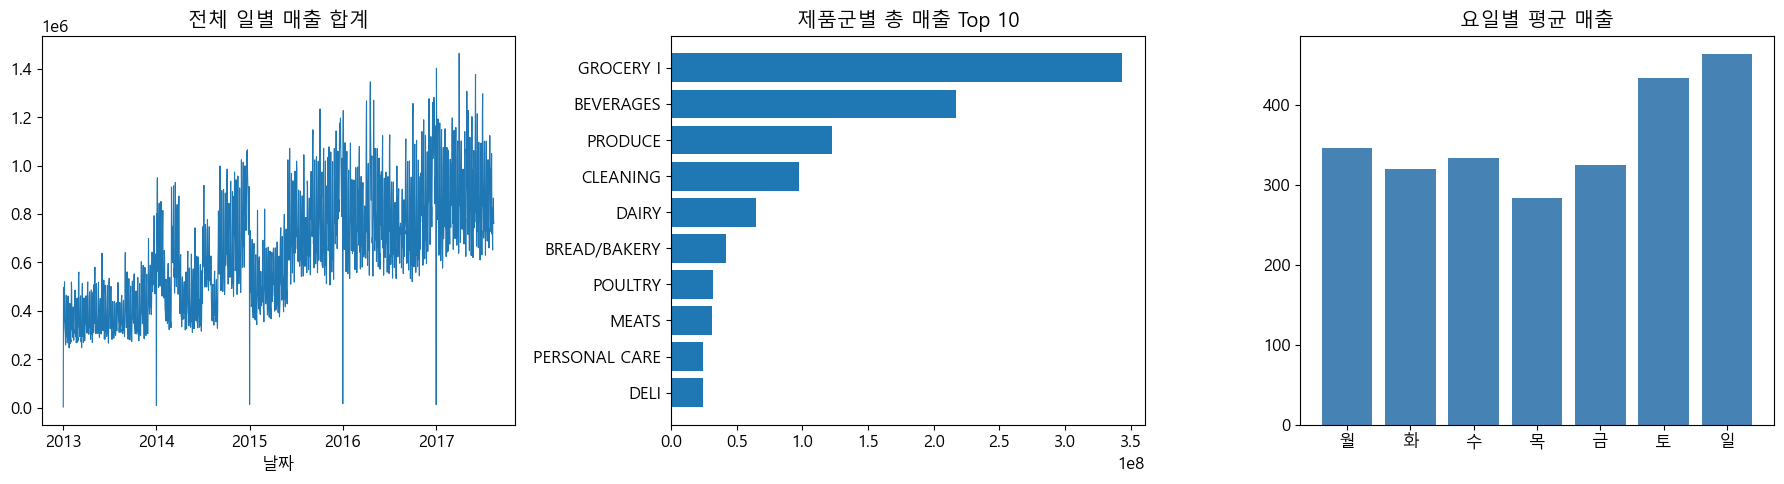

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# OS별 자동 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    # 나눔폰트 설치 필요: sudo apt-get install fonts-nanum
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
# -------------그래프 글씨 깨짐방지

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 전체 일별 매출 추이
daily = train.groupby('date')['sales'].sum()
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title('전체 일별 매출 합계')
axes[0].set_xlabel('날짜')

# 2) 제품군별 총 매출 Top 10
family_sales = train.groupby('family')['sales'].sum().nlargest(10)
axes[1].barh(family_sales.index, family_sales.values)
axes[1].set_title('제품군별 총 매출 Top 10')
axes[1].invert_yaxis()

# 3) 요일별 평균 매출
train['dayofweek'] = train['date'].dt.dayofweek
dow = train.groupby('dayofweek')['sales'].mean()
dow.index = ['월','화','수','목','금','토','일']
axes[2].bar(dow.index, dow.values, color='steelblue')
axes[2].set_title('요일별 평균 매출')

plt.tight_layout()
plt.show()

1. 전체 일별 매출 : 2014~2015 매출 급락 / 도메인 : 에콰도르 대지진
2. 제품군 : grocery식료품, beverages음료, produce농산물
3. 요일별 패턴 : 주말 매출 높음

## <b> 이상치확인

In [6]:
# 일별 매출 합계
daily = train.groupby('date')['sales'].sum()

# 매출이 특히 낮은 날 Top 10
print(daily.nsmallest(10).sort_index())

date
2013-01-01      2511.618999
2013-01-10    258982.003049
2013-01-24    247245.690995
2013-01-29    264488.818076
2013-03-14    247541.420096
2013-06-27    266525.458966
2014-01-01      8602.065404
2015-01-01     12773.616980
2016-01-01     16433.394000
2017-01-01     12082.500997
Name: sales, dtype: float64


In [7]:
# 지진 날짜2016/4/16 전후 확인
quake = daily['2016-04-10':'2016-04-25']
print(quake)
#4월 16일 → 8.621215e+05  =  862,121
#4월 17일 → 1.271834e+06  = 1,271,834 지진 후 급등

date
2016-04-10    1.008877e+06
2016-04-11    6.653490e+05
2016-04-12    6.516570e+05
2016-04-13    6.726115e+05
2016-04-14    5.467852e+05
2016-04-15    6.676063e+05
2016-04-16    8.621215e+05
2016-04-17    1.271834e+06
2016-04-18    1.345921e+06
2016-04-19    1.152089e+06
2016-04-20    1.062426e+06
2016-04-21    1.001080e+06
2016-04-22    8.570592e+05
2016-04-23    1.022143e+06
2016-04-24    1.039370e+06
2016-04-25    6.800008e+05
Name: sales, dtype: float64


## <b> 결측확인

In [8]:
for name, df in [('train', train), ('test', test), ('stores', stores),
                 ('oil', oil), ('holidays', holidays), ('transactions', transactions)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]  # 결측 있는 컬럼만 출력
    if len(missing) > 0:
        print(f"[{name}]")
        print(missing)
        print(f"비율: {(missing/len(df)*100).round(1).to_string()}")
    else:
        print(f"[{name}] 결측 없음")
    print()

[train] 결측 없음

[test] 결측 없음

[stores] 결측 없음

[oil]
dcoilwtico    43
dtype: int64
비율: dcoilwtico    3.5

[holidays] 결측 없음

[transactions] 결측 없음



In [9]:
# train 날짜에 holidays 붙여보기
train_with_holiday = train[['date']].drop_duplicates().merge(
    holidays, on='date', how='left'
)
print(train_with_holiday.isnull().sum())
print(f"전체 날짜 중 공휴일 비율: {train_with_holiday['type'].notna().mean()*100:.1f}%")

date              0
type           1432
locale         1432
locale_name    1432
description    1432
transferred    1432
dtype: int64
전체 날짜 중 공휴일 비율: 16.5%


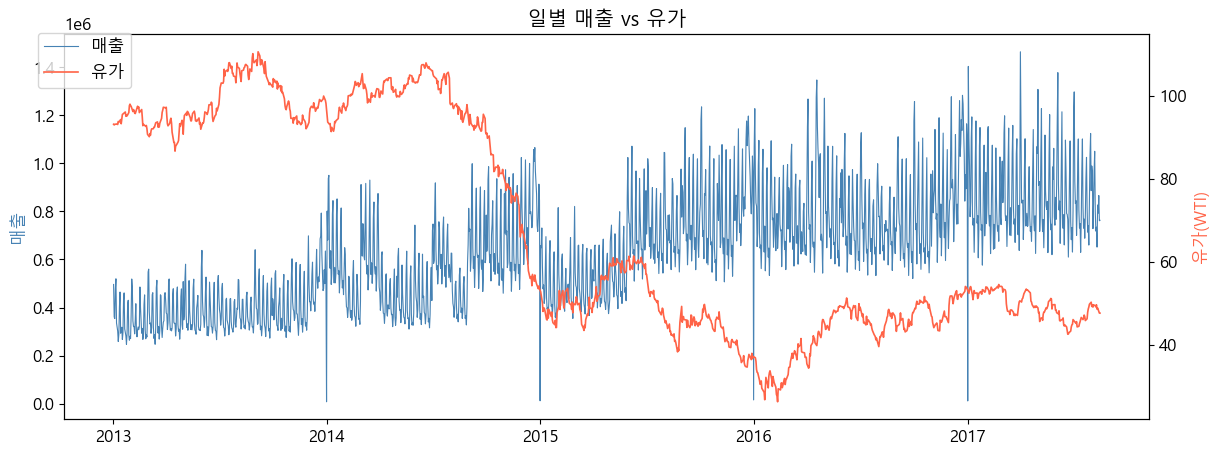

In [10]:
# oil 결측치 채우기 (공휴일에 유가 데이터 없음)
oil_filled = oil.set_index('date')['dcoilwtico'].resample('D').interpolate()

# 일별 매출과 합치기
compare = pd.DataFrame({
    'sales': daily,
    'oil': oil_filled
}).dropna()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(compare.index, compare['sales'], color='steelblue', linewidth=0.8, label='매출')
ax1.set_ylabel('매출', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(compare.index, compare['oil'], color='tomato', linewidth=1.2, label='유가')
ax2.set_ylabel('유가(WTI)', color='tomato')

plt.title('일별 매출 vs 유가')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

<pre>
도메인 : 에콰도르 산유국이라 유가가 높으면 경기가 좋고 소비가 증가함
유가는 매출과 음의 상관관계
결측은 앞의 날짜로 채우기(ffill)

# <b> 피처 엔지니어링

## 테이블 합치기

In [11]:
print(oil['dcoilwtico'].isnull().sum())  
print(oil_filled.isnull().sum())        

43
1


In [12]:
# 1) oil 결측 채우기
oil_clean = oil_filled.reset_index()
oil_clean.columns = ['date', 'dcoilwtico']

# 2) 전국 공휴일만 추출
national_holidays = holidays[
    (holidays['locale'] == 'National') & 
    (holidays['transferred'] == False)
][['date', 'type', 'description']].rename(columns={'type': 'holiday_type'})

# 3) 베이스 테이블 합치기
df = train.copy()
df = df.merge(stores,            how='left',  on='store_nbr')
df = df.merge(oil_clean,         how='left',  on='date') 
df = df.merge(national_holidays, how='left',  on='date')

print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(3008016, 14)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'dayofweek', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'holiday_type', 'description']
   id       date  store_nbr      family  sales  onpromotion  dayofweek   city  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0          1  Quito   
1   1 2013-01-01          1   BABY CARE    0.0            0          1  Quito   
2   2 2013-01-01          1      BEAUTY    0.0            0          1  Quito   

       state type  cluster  dcoilwtico holiday_type         description  
0  Pichincha    D       13         NaN      Holiday  Primer dia del ano  
1  Pichincha    D       13         NaN      Holiday  Primer dia del ano  
2  Pichincha    D       13         NaN      Holiday  Primer dia del ano  


<pre>
[train]  shape: (3000888, 7) -> (3008016, 14) 행이 늘어남
    => holidays에 같은 날짜 여러 개라 복제됨
    ex) 2013-01-01  Holiday   Primer dia del ano
        2013-01-01  Additional  Año Nuevo Event 

In [13]:
print(df['dcoilwtico'].isnull().sum())

1782


In [14]:
# 날짜 중복 제거 (첫 번째 행만 유지)
national_holidays = national_holidays.drop_duplicates('date', keep='first')

# 다시 merge
df = train.copy()
df = df.merge(stores,            on='store_nbr', how='left')
df = df.merge(oil_clean,         on='date',      how='left')
df = df.merge(national_holidays, on='date',      how='left')

print(df.shape) 

(3000888, 14)


## 날짜 피쳐

In [15]:
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day']         = df['date'].dt.day
df['dayofweek']   = df['date'].dt.dayofweek   # 0=월 ~ 6=일
df['weekofyear']  = df['date'].dt.isocalendar().week.astype(int) # 1년 중 몇번째 주인지 확인 계절성을 잡기 위해 - 1:신년, 25:여름, 52:크리스마스
df['is_weekend']  = (df['dayofweek'] >= 5).astype(int) #주말패턴잡기(매출주말이 높음)
df['is_holiday']  = df['holiday_type'].notna().astype(int) #공휴일패턴(휴일 매출)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int) # 도메인 - 월급이 월초에 지급되는경우가 많음
df['is_month_end']   = df['date'].dt.is_month_end.astype(int) # 월말 재고소진이나 소비패턴

print(df[['date','year','month','day','dayofweek','is_weekend','is_holiday']].head(7))

        date  year  month  day  dayofweek  is_weekend  is_holiday
0 2013-01-01  2013      1    1          1           0           1
1 2013-01-01  2013      1    1          1           0           1
2 2013-01-01  2013      1    1          1           0           1
3 2013-01-01  2013      1    1          1           0           1
4 2013-01-01  2013      1    1          1           0           1
5 2013-01-01  2013      1    1          1           0           1
6 2013-01-01  2013      1    1          1           0           1


## lag 피쳐
* 과거의 매출을 피처로 쓰는 것
* 매장 * 제품군 단위로 만들어야함(아니면 품목이랑 가격이 섞임)

In [16]:
# lag 피처 (매장×제품군 단위)
for lag in [7, 14, 28]:
    df[f'lag_{lag}'] = df.groupby(['store_nbr','family'])['sales'].shift(lag)

# 확인
print(df[['date','store_nbr','family','sales','lag_7','lag_14','lag_28']].head(20))
print(f"\nlag_7 결측: {df['lag_7'].isnull().sum():,}개")
print(f"lag_14 결측: {df['lag_14'].isnull().sum():,}개")
print(f"lag_28 결측: {df['lag_28'].isnull().sum():,}개")

         date  store_nbr               family  sales  lag_7  lag_14  lag_28
0  2013-01-01          1           AUTOMOTIVE    0.0    NaN     NaN     NaN
1  2013-01-01          1            BABY CARE    0.0    NaN     NaN     NaN
2  2013-01-01          1               BEAUTY    0.0    NaN     NaN     NaN
3  2013-01-01          1            BEVERAGES    0.0    NaN     NaN     NaN
4  2013-01-01          1                BOOKS    0.0    NaN     NaN     NaN
5  2013-01-01          1         BREAD/BAKERY    0.0    NaN     NaN     NaN
6  2013-01-01          1          CELEBRATION    0.0    NaN     NaN     NaN
7  2013-01-01          1             CLEANING    0.0    NaN     NaN     NaN
8  2013-01-01          1                DAIRY    0.0    NaN     NaN     NaN
9  2013-01-01          1                 DELI    0.0    NaN     NaN     NaN
10 2013-01-01          1                 EGGS    0.0    NaN     NaN     NaN
11 2013-01-01          1         FROZEN FOODS    0.0    NaN     NaN     NaN
12 2013-01-0

<pre>
lag로 같은 요일의 패턴 포착 가능
    오늘이 월요일이면
    lag_7  = 지난주 월요일 매출
    lag_14 = 2주 전 월요일 매출
    lag_28 = 4주 전 월요일 매출
초반 결측은 트리모델이 자체 처리해서 결측처리 안해도 됨

In [17]:
# 매장1, BEVERAGES만 뽑아서 확인
sample = df[(df['store_nbr']==1) & (df['family']=='BEVERAGES')]\
           [['date','sales','lag_7','lag_14','lag_28']].head(35)
print(sample) #1/8의 log7이 1/1의 sales이어야 함

            date   sales   lag_7  lag_14  lag_28
3     2013-01-01     0.0     NaN     NaN     NaN
1785  2013-01-02  1091.0     NaN     NaN     NaN
3567  2013-01-03   919.0     NaN     NaN     NaN
5349  2013-01-04   953.0     NaN     NaN     NaN
7131  2013-01-05  1160.0     NaN     NaN     NaN
8913  2013-01-06   407.0     NaN     NaN     NaN
10695 2013-01-07  1158.0     NaN     NaN     NaN
12477 2013-01-08  1029.0     0.0     NaN     NaN
14259 2013-01-09  1186.0  1091.0     NaN     NaN
16041 2013-01-10   847.0   919.0     NaN     NaN
17823 2013-01-11  1033.0   953.0     NaN     NaN
19605 2013-01-12  1143.0  1160.0     NaN     NaN
21387 2013-01-13   572.0   407.0     NaN     NaN
23169 2013-01-14  1178.0  1158.0     NaN     NaN
24951 2013-01-15  1149.0  1029.0     0.0     NaN
26733 2013-01-16  1043.0  1186.0  1091.0     NaN
28515 2013-01-17   898.0   847.0   919.0     NaN
30297 2013-01-18  1130.0  1033.0   953.0     NaN
32079 2013-01-19  1280.0  1143.0  1160.0     NaN
33861 2013-01-20   4

## 롤링 피처

In [20]:
# 롤링 피처 (매장×제품군 단위)로 묶기 => 그룹마다 독립적인 시계열 만듬
for window in [7, 28]: 
    # 평균 판매량
    df[f'rolling_mean_{window}'] = df.groupby(['store_nbr','family'])['sales']\
                                     .transform(lambda x: x.shift(1).rolling(window).mean()) # 원래 데이터 길이 그대로 변환
    # 판매 변동성 
    df[f'rolling_std_{window}']  = df.groupby(['store_nbr','family'])['sales']\
                                     .transform(lambda x: x.shift(1).rolling(window).std()) # shift하는 이유 : 과거의 데이터만 사용, 값 한칸 아래로 밀기=하루 전 값
                                      
print(df[['date','store_nbr','family','sales',
          'rolling_mean_7','rolling_std_7',
          'rolling_mean_28','rolling_std_28']].iloc[1800:1810])

           date  store_nbr                   family    sales  rolling_mean_7  \
1800 2013-01-02          1                HOME CARE    0.000             NaN   
1801 2013-01-02          1               LADIESWEAR    0.000             NaN   
1802 2013-01-02          1          LAWN AND GARDEN   10.000             NaN   
1803 2013-01-02          1                 LINGERIE   13.000             NaN   
1804 2013-01-02          1         LIQUOR,WINE,BEER   67.000             NaN   
1805 2013-01-02          1                MAGAZINES    0.000             NaN   
1806 2013-01-02          1                    MEATS  369.101             NaN   
1807 2013-01-02          1            PERSONAL CARE  194.000             NaN   
1808 2013-01-02          1             PET SUPPLIES    0.000             NaN   
1809 2013-01-02          1  PLAYERS AND ELECTRONICS    0.000             NaN   

      rolling_std_7  rolling_mean_28  rolling_std_28  
1800            NaN              NaN             NaN  
1801     

## 외부변수 피처

In [22]:
# 0) 공휴일 날짜 집합 먼저 정의
holiday_dates = set(national_holidays['date'])

# 1) 유가 변화율 : 유가 가격, 상승하강 방향 중요
df['oil_diff']    = df['dcoilwtico'].diff()           # 전날 대비 변화량
df['oil_pct']     = df['dcoilwtico'].pct_change()     # 전날 대비 변화율(%)

# 2) 공휴일 전후 효과
df['is_before_holiday'] = df['date'].apply(
    lambda x: 1 if (x + pd.Timedelta(days=1)) in holiday_dates else 0) # 내일이 공휴일
df['is_after_holiday'] = df['date'].apply(
    lambda x: 1 if (x - pd.Timedelta(days=1)) in holiday_dates else 0)  # 어제가 공휴일

# 3) 프로모션 rolling (최근 7일간 프로모션 횟수)
df['promo_7'] = df.groupby(['store_nbr','family'])['onpromotion']\
                  .transform(lambda x: x.shift(1).rolling(7).sum())

# 확인
print(df[['date','dcoilwtico','oil_diff','oil_pct',
          'is_holiday','is_before_holiday','is_after_holiday',
          'onpromotion','promo_7']].drop_duplicates('date').head(15))

            date  dcoilwtico  oil_diff   oil_pct  is_holiday  \
0     2013-01-01         NaN       NaN       NaN           1   
1782  2013-01-02   93.140000       NaN       NaN           0   
3564  2013-01-03   92.970000 -0.170000 -0.001825           0   
5346  2013-01-04   93.120000  0.150000  0.001613           0   
7128  2013-01-05   93.146667  0.026667  0.000286           1   
8910  2013-01-06   93.173333  0.026667  0.000286           0   
10692 2013-01-07   93.200000  0.026667  0.000286           0   
12474 2013-01-08   93.210000  0.010000  0.000107           0   
14256 2013-01-09   93.080000 -0.130000 -0.001395           0   
16038 2013-01-10   93.810000  0.730000  0.007843           0   
17820 2013-01-11   93.600000 -0.210000 -0.002239           0   
19602 2013-01-12   93.823333  0.223333  0.002386           1   
21384 2013-01-13   94.046667  0.223333  0.002380           0   
23166 2013-01-14   94.270000  0.223333  0.002375           0   
24948 2013-01-15   93.260000 -1.010000 -

In [23]:
# 1월 1일 전후만 뽑기
check = df.drop_duplicates('date')[['date','is_holiday','is_before_holiday','is_after_holiday']]
print(check[check['date'].between('2013-12-30','2014-01-03')])

             date  is_holiday  is_before_holiday  is_after_holiday
645084 2013-12-30           0                  1                 0
646866 2013-12-31           1                  1                 0
648648 2014-01-01           1                  0                 1
650430 2014-01-02           0                  0                 1
652212 2014-01-03           0                  0                 0


In [24]:
print(national_holidays[national_holidays['date'].between('2013-12-29','2014-01-02')])

         date holiday_type           description
91 2013-12-31   Additional  Primer dia del ano-1
92 2014-01-01      Holiday    Primer dia del ano


신정 전날 추가 공휴일로 지정 따라서 12/31, 1/1공휴일

# <b> 인코딩

In [25]:
print(df.select_dtypes(include='object').columns.tolist()) # 문자열 컬럼 ->숫자로 변환
print(df.shape) # 피쳐 34개

['family', 'city', 'state', 'type', 'holiday_type', 'description']
(3000888, 34)


In [26]:
from sklearn.preprocessing import LabelEncoder

# description 삭제
df = df.drop(columns=['description']) # 공휴일 이름이라 삭제

# 나머지 Label Encoding
le = LabelEncoder()
for col in ['family', 'city', 'state', 'type', 'holiday_type']:
    df[col] = df[col].fillna('NONE')   # NaN → 'NONE' 문자열로
    df[col] = le.fit_transform(df[col])

# 확인
print(df.select_dtypes(include='object').columns.tolist())  # 비어있어야 함
print(df.shape)
print(df[['family','city','state','type','holiday_type']].head(3)) #문자열들 숫자로 변환

[]
(3000888, 33)
   family  city  state  type  holiday_type
0       0    18     12     3             3
1       1    18     12     3             3
2       2    18     12     3             3


In [27]:
print(df.columns.tolist())
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'dayofweek', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'holiday_type', 'year', 'month', 'day', 'weekofyear', 'is_weekend', 'is_holiday', 'is_month_start', 'is_month_end', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'oil_diff', 'oil_pct', 'is_before_holiday', 'is_after_holiday', 'promo_7']
(3000888, 33)
dcoilwtico          1782
lag_7              12474
lag_14             24948
lag_28             49896
rolling_mean_7     12474
rolling_std_7      12474
rolling_mean_28    49896
rolling_std_28     49896
oil_diff            1783
oil_pct             1783
promo_7            12474
dtype: int64


<pre>
결측정리
dcoilwtico          1782 : 2013-01-01 유가 없음
lag_7              12474 : 초반 7일치 없음 
lag_14             24948 : 초반 14일 
lag_28             49896 : 초반 28일 
rolling_mean_7     12474 : 초반 7일치 없음 
rolling_std_7      12474 : 초반 7일치 없음 
rolling_mean_28    49896 : 초반 28일
rolling_std_28     49896 : 초반 28일
oil_diff            1783 : 유가 결측 + 첫날 계산 불가
oil_pct             1783 : 유가 결측 + 첫날 계산 불가
promo_7            12474 : rolling(최근데이터로 평균계산)이라 초반 7일 없음
모델이 자체 처리함

# <b> 모델링
* LightGBM - 데이터 적어도 학습 잘함, 결측 자동처리가능, 조건 패턴 잘 학습, 다중시계열에 강함

In [31]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'dayofweek', 'city', 'state', 'type', 'cluster', 'dcoilwtico',
       'holiday_type', 'year', 'month', 'day', 'weekofyear', 'is_weekend',
       'is_holiday', 'is_month_start', 'is_month_end', 'lag_7', 'lag_14',
       'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28',
       'rolling_std_28', 'oil_diff', 'oil_pct', 'is_before_holiday',
       'is_after_holiday', 'promo_7'],
      dtype='object')

<pre>
date - 날짜피처로 분해해서 제외
id - 의미없어서 제외
sales - 타겟이라 제외

In [34]:
# 사용할 피처 목록
features = ['store_nbr', 'family', 'onpromotion', 'dayofweek',
            'city', 'state', 'type', 'cluster', 'dcoilwtico',
            'holiday_type', 'year', 'month', 'day', 'weekofyear',
            'is_weekend', 'is_holiday', 'is_month_start', 'is_month_end',
            'lag_7', 'lag_14', 'lag_28',
            'rolling_mean_7', 'rolling_std_7',
            'rolling_mean_28', 'rolling_std_28',
            'oil_diff', 'oil_pct',
            'is_before_holiday', 'is_after_holiday', 'promo_7']

# 마지막 31일을 검증셋으로 (2017-07-16 ~ 2017-08-15),원래예측기간(2017-08-16 ~ 2017-08-31)보다 넉넉하게 잡기
# 만든 피처 lag_28까지 값이 온전히 채워지는 구간을 검증셋으로 쓰려고
cutoff = '2017-07-15'

#데이터 분리
train_data = df[df['date'] <= cutoff] #2013 ~ 2017/7/15
valid_data = df[df['date'] >  cutoff] #2017/7/16 ~

#X,y분리
X_train = train_data[features]
y_train = train_data['sales']
X_valid = valid_data[features]
y_valid = valid_data['sales']

print(f"학습셋: {X_train.shape}") # 2013/01/01 ~ 2017/07/15
print(f"검증셋: {X_valid.shape}") # 2017/07/16 ~ 2017/08/15

학습셋: (2945646, 30)
검증셋: (55242, 30)


In [35]:
print(f"검증셋 날짜 범위: {valid_data['date'].min()} ~ {valid_data['date'].max()}")
print(f"검증셋 날짜 수: {valid_data['date'].nunique()}일")
print(f"날짜 수 × 1782: {valid_data['date'].nunique() * 1782}")

검증셋 날짜 범위: 2017-07-16 00:00:00 ~ 2017-08-15 00:00:00
검증셋 날짜 수: 31일
날짜 수 × 1782: 55242


In [38]:
#!pip install lightgbm

In [40]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [41]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.109242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2850
[LightGBM] [Info] Number of data points in the train set: 2945646, number of used features: 30
[LightGBM] [Info] Start training from score 355.629570
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 46943.1
[200]	valid_0's l2: 45465.9
[300]	valid_0's l2: 44464
[400]	valid_0's l2: 43286.6
[500]	valid_0's l2: 42799.9
[600]	valid_0's l2: 42291.5
[700]	valid_0's l2: 41845.1
[800]	valid_0's l2: 41228.2
Early stopping, best iteration is:
[838]	valid_0's l2: 41094.1


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [42]:
# 위에 valid_0's l2이거 평가지표는 RMSLE인데 12(MSE)로 학습함
from sklearn.metrics import mean_squared_log_error
import numpy as np

y_pred = model.predict(X_valid)
y_pred = np.clip(y_pred, 0, None)  # 음수 예측값 0으로 클리핑

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_pred))
print(f"검증 RMSLE: {rmsle:.4f}")

검증 RMSLE: 0.5692
